Using instance segmentation to separate pets

In [ ]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchvision.ops import nms
from PIL import Image
import matplotlib.colors as mcolors
from scipy.ndimage import label
from torchvision.datasets import OxfordIIITPet

Getting the dataset and split it

In [ ]:
class PetDatasetWithSpecies(OxfordIIITPet):
    def __getitem__(self, idx):
        img, mask = super().__getitem__(idx)
        filename = self._images[idx].name
        #uppercase first letter = cat, lowercase = dog
        # 1=cat, 2=dog
        species = 1 if filename[0].isupper() else 2
        return img, mask, species

data_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
mask_transform = T.Compose([
    T.Resize((256, 256), interpolation=InterpolationMode.NEAREST),
    T.ToTensor()
])

#use custom class, not OxfordIIITPet directly
dataset = PetDatasetWithSpecies(
    root="./data",
    target_types="segmentation",
    download=True,
    transform=data_transform,
    target_transform=mask_transform
)

#Only take 200 picture as my computer got limited computation resources
subset_indices = list(range(200))
small_dataset  = torch.utils.data.Subset(dataset, subset_indices)

train_size = 190
test_size  = 10

train_dataset, test_dataset = torch.utils.data.random_split(
    small_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
img, mask, species = train_dataset[0]
print(f"Species label: {species} ({'Cat' if species == 1 else 'Dog'})")
print(len(train_dataset))
print(len(test_dataset))

Train: 190 | Test: 10
Species label: 2 (Dog)
190
10


Below is to load the train data

In [ ]:
train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))  #(imgs, masks, species_labels)
)

In [ ]:
images, targets, Labels = next(iter(train_loader))
print(f"Images in one batch: {len(images)}")
print(f"Each image shape: {images[0].shape}")
print(f"Labels in batch: {Labels[0]}") #Either 1(cat) or 2(dog)

Images in one batch: 4
Each image shape: torch.Size([3, 256, 256])
Labels in batch: 2


Below code defining the model

In [ ]:
def get_model(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    #Freeze backbone (from v1)
    for param in model.backbone.parameters():
        param.requires_grad = False
    #Freeze the RPN so it stops proposing hundreds of
    #candidate regions that the undertrained classifier cannot reject.
    for param in model.rpn.parameters():
        param.requires_grad = False

    #the number of region proposals at inference.
    #Default values (1000 / 1000 / 100) are tuned for COCO's 80 classes —
    #way too many for a binary pet/background task.
    model.rpn.pre_nms_top_n_test        = 1000
    #default: 1000
    model.rpn.post_nms_top_n_test       = 1000
    #default: 1000
    model.roi_heads.detections_per_img  = 50
    #default: 100
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    return model

Train the model using the training set

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

model = get_model(num_classes=3)
model.to(device)
# collect trainable params as a plain list — filter() returns a
# one-shot generator that gets exhausted after the first optimizer step,
# causing the loop to silently stall from epoch 2 onward.
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable parameter groups: {len(trainable_params)}")

optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


def prepare_targets(images_list, targets, species_labels, device):
    valid_images, valid_targets = [], []

    for img, t, species in zip(images_list, targets, species_labels):
        #It isolates only the pet pixels and throws away the background and borders.
        #when we pass the image through PyTorch's ToTensor() function,
        #it automatically divides all pixel values by 255.0 to normalize them between 0 and 1.
        #This code creates a logical "AND" gate (using the * multiplier).
        #Is the pixel value less than 2/255 AND greater than 0.5/255?
        #The only value that satisfies both conditions is exactly 1/255 (the pet foreground).
        #The .float() turns the resulting True/False answers into 1.0 (pet) and 0.0 (everything else).
        binary_mask = (t < (2 / 255.0)).float() * (t > (0.5 / 255.0)).float()

        #It prepares the PyTorch tensor so that the Scipy library can read it.
        #The tensor likely has a shape of [1, Height, Width] (1 color channel).
        #The [0] strips away that extra "1" dimension, leaving a [Height, Width].
        #numpy(), Converts the PyTorch Tensor object into a standard NumPy array.
        mask_np = binary_mask[0].cpu().numpy()

        #finds individual, separate pets within that binary mask using
        #a classic image processing technique called Connected Component Labeling.
        #This function scans the 2D array looking for "blobs" of connected 1s.
        #If you have two dogs in the image, the binary_mask just sees them both
        #as 1s. The label() function treats them as islands.
        #labeled_mask, new array returned by the function.
        #Instead of just 1s and 0s, it now contains 0s (background), 1s (Pet A), 2s (Pet B), etc.
        #num_instances, num of islands
        labeled_mask, num_instances = label(mask_np)

        if num_instances == 0:
            continue

        boxes, masks, labels = [], [], []
        for i in range(1, num_instances + 1):
            instance_mask = (labeled_mask == i) #Focus only to the pixels equal to i (1,2, or 3)
            pos = np.where(instance_mask) #To get the x,y coordinate of every single True pet pixels
            #pos[0] = Y, pos[1] = X
            #If the Y coordinate is 0 or 0 pixels
            if pos[0].size == 0:
                continue
            #calculates the smallest possible rectangle that can completely surround the pet.
            ymin, ymax = np.min(pos[0]), np.max(pos[0])
            xmin, xmax = np.min(pos[1]), np.max(pos[1])
            #Checks if the bounding box has an area of zero (a line that is 1 pixel wide).
            if xmin == xmax or ymin == ymax:
                continue
            boxes.append([xmin, ymin, xmax, ymax])
            masks.append(instance_mask)
            labels.append(species)

        if len(boxes) == 0:
            continue

        valid_images.append(img)
        valid_targets.append({
            "boxes":  torch.tensor(boxes, dtype=torch.float32).to(device),
            "labels": torch.tensor(labels, dtype=torch.int64).to(device),
            "masks":  torch.tensor(np.array(masks), dtype=torch.float32).to(device)
        })

    return valid_images, valid_targets

model.train()
NUM_EPOCHS = 2

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    skipped    = 0
    batches    = 0

    for i, (images, targets, species_labels) in enumerate(train_loader):
        images = [img.to(device) for img in images]

        valid_images, valid_targets = prepare_targets(images, targets, species_labels, device)

        if len(valid_targets) == 0:
            skipped += 1
            continue

        loss_dict = model(valid_images, valid_targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        batches    += 1
        if i % 10 == 0:
            print(f"  Epoch {epoch+1} | Batch {i} | Loss: {losses.item():.4f}", flush=True)

    avg_loss = epoch_loss / batches if batches > 0 else float('nan')
    if batches > 0:
        scheduler.step()
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] — Avg Loss: {avg_loss:.4f} | Skipped: {skipped}", flush=True)

Using device: cpu
Trainable parameter groups: 20
  Epoch 1 | Batch 0 | Loss: 6.4744
  Epoch 1 | Batch 10 | Loss: 1.3367
  Epoch 1 | Batch 20 | Loss: 0.3832
  Epoch 1 | Batch 30 | Loss: 0.5561
  Epoch 1 | Batch 40 | Loss: 0.3255
Epoch [1/2] — Avg Loss: 1.2869 | Skipped: 0
  Epoch 2 | Batch 0 | Loss: 0.2969
  Epoch 2 | Batch 10 | Loss: 1.2819
  Epoch 2 | Batch 20 | Loss: 0.3155
  Epoch 2 | Batch 30 | Loss: 3.1094
  Epoch 2 | Batch 40 | Loss: 1.8982
Epoch [2/2] — Avg Loss: 1.0000 | Skipped: 0


Test the model

Detected 1 cat(s) and 1 dog(s) with score > 0.5


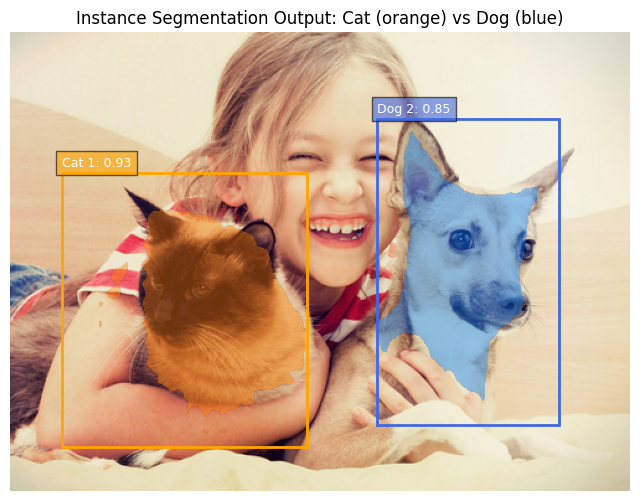

In [ ]:
img = Image.open("catdoghuman.jpg").convert("RGB")
img_tensor = T.ToTensor()(img).to(device)

LABEL_NAMES = {1: "Cat", 2: "Dog"}
LABEL_COLORS = {1: 'orange', 2: 'royalblue'}
MASK_COLORS  = {1: [1, 0.5, 0, 0.4], 2: [0, 0.5, 1, 0.4]}  # orange / blue tint

SCORE_THRESHOLD   = 0.5
NMS_IOU_THRESHOLD = 0.15

model.eval()
with torch.no_grad():
    prediction = model([img_tensor])

boxes       = prediction[0]['boxes']
scores      = prediction[0]['scores']
masks       = prediction[0]['masks']
pred_labels = prediction[0]['labels']   #retrieve predicted class labels

# filter by confidence
keep        = scores > SCORE_THRESHOLD
boxes       = boxes[keep]
scores      = scores[keep]
masks       = masks[keep]
pred_labels = pred_labels[keep]         # <-- filter labels too

# explicit NMS
if len(boxes) > 0:
    keep_nms    = nms(boxes, scores, iou_threshold=NMS_IOU_THRESHOLD)
    boxes       = boxes[keep_nms].cpu().numpy()
    scores      = scores[keep_nms].cpu().numpy()
    masks       = masks[keep_nms].cpu().numpy()
    pred_labels = pred_labels[keep_nms].cpu().numpy()   # <-- apply NMS filter
else:
    boxes       = boxes.cpu().numpy()
    scores      = scores.cpu().numpy()
    masks       = masks.cpu().numpy()
    pred_labels = pred_labels.cpu().numpy()

img_display = img_tensor.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(img_display)
ax = plt.gca()

if len(boxes) == 0:
    print("No confident detections. Try more epochs or lower SCORE_THRESHOLD.")
else:
    for i, (box, score, mask, label_id) in enumerate(zip(boxes, scores, masks, pred_labels)):
        species = LABEL_NAMES.get(label_id, "Pet")
        color   = LABEL_COLORS.get(label_id, 'red')

        rect = plt.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            fill=False, color=color, linewidth=2
        )
        ax.add_patch(rect)
        plt.text(
            box[0], box[1] - 5,
            f'{species} {i+1}: {score:.2f}',   #"Cat" / "Dog" instead of "Pet"
            color='white', fontsize=9,
            bbox=dict(facecolor=color, alpha=0.6)
        )

        mask_display = mask[0] > 0.5
        colored_mask = np.zeros((*mask_display.shape, 4))
        colored_mask[mask_display] = MASK_COLORS.get(label_id, [0, 1, 0, 0.4])   # <-- species color
        ax.imshow(colored_mask)

    cats = sum(1 for l in pred_labels if l == 1)
    dogs = sum(1 for l in pred_labels if l == 2)
    print(f"Detected {cats} cat(s) and {dogs} dog(s) with score > {SCORE_THRESHOLD}")

plt.title("Instance Segmentation Output: Cat (orange) vs Dog (blue)")
plt.axis('off')
plt.show()